In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# Chargement des données
df = pd.read_csv('processed_data/Production_Cleaned.csv', low_memory=False)
df['DEBUT_PERI'] = pd.to_datetime(df['DEBUT_PERI'], errors='coerce')
df = df[df['DEBUT_PERI'].dt.year == 2025]
df['Mois'] = df['DEBUT_PERI'].dt.to_period('M')
monthly = df.groupby('Mois')['PRIME_NETTE'].sum().reset_index()
monthly.columns = ['Mois', 'CA']
monthly['ds'] = monthly['Mois'].dt.to_timestamp()
monthly = monthly.sort_values('ds').reset_index(drop=True)

print(f"✅ {len(monthly)} mois de données")
print(monthly[['ds', 'CA']])

Importing plotly failed. Interactive plots will not work.


✅ 12 mois de données
           ds          CA
0  2025-01-01  1637051493
1  2025-02-01  1415393917
2  2025-03-01  1676940225
3  2025-04-01  1571376609
4  2025-05-01  1560040807
5  2025-06-01  1484329372
6  2025-07-01  1620005579
7  2025-08-01  1661292970
8  2025-09-01  1762731261
9  2025-10-01  1758090467
10 2025-11-01  1694978908
11 2025-12-01  1713931223


In [2]:
# =============================================
# MODÈLE 1 : RÉGRESSION LINÉAIRE SAISONNIÈRE
# =============================================
def make_features(ds_series, t_offset=0):
    t = np.arange(t_offset, t_offset + len(ds_series))
    month = ds_series.dt.month.values
    X = np.column_stack([
        t,
        np.sin(2 * np.pi * month / 12),
        np.cos(2 * np.pi * month / 12),
    ])
    return X

X = make_features(monthly['ds'])
y = monthly['CA'].values

lr_model = LinearRegression()
lr_model.fit(X, y)
lr_pred = lr_model.predict(X)

lr_mae  = mean_absolute_error(y, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y, lr_pred))
lr_r2   = r2_score(y, lr_pred)

print(f"📊 Régression Linéaire :")
print(f"   MAE  : {lr_mae/1e6:.2f}M TND")
print(f"   RMSE : {lr_rmse/1e6:.2f}M TND")
print(f"   R²   : {lr_r2:.3f}")

📊 Régression Linéaire :
   MAE  : 49.79M TND
   RMSE : 69.55M TND
   R²   : 0.533


In [3]:
# =============================================
# MODÈLE 2 : SARIMA
# =============================================
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    monthly['CA'],
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
sarima_pred = sarima_fit.fittedvalues

sarima_mae  = mean_absolute_error(y, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(y, sarima_pred))
sarima_r2   = r2_score(y, sarima_pred)

print(f"📊 SARIMA :")
print(f"   MAE  : {sarima_mae/1e6:.2f}M TND")
print(f"   RMSE : {sarima_rmse/1e6:.2f}M TND")
print(f"   R²   : {sarima_r2:.3f}")

📊 SARIMA :
   MAE  : 353.09M TND
   RMSE : 531.25M TND
   R²   : -26.262


In [4]:
# =============================================
# MODÈLE 3 : PROPHET
# =============================================
df_prophet = monthly[['ds', 'CA']].rename(columns={'CA': 'y'})

prophet_model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=0.1,
)
prophet_model.add_seasonality(name='monthly', period=30.5, fourier_order=3)
prophet_model.fit(df_prophet)

prophet_forecast = prophet_model.predict(df_prophet)
prophet_pred = prophet_forecast['yhat'].values

prophet_mae  = mean_absolute_error(y, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(y, prophet_pred))
prophet_r2   = r2_score(y, prophet_pred)

print(f"📊 Prophet :")
print(f"   MAE  : {prophet_mae/1e6:.2f}M TND")
print(f"   RMSE : {prophet_rmse/1e6:.2f}M TND")
print(f"   R²   : {prophet_r2:.3f}")

23:28:53 - cmdstanpy - INFO - Chain [1] start processing
23:28:57 - cmdstanpy - INFO - Chain [1] done processing


📊 Prophet :
   MAE  : 60.27M TND
   RMSE : 75.72M TND
   R²   : 0.446


             Modèle  MAE (M TND)  RMSE (M TND)      R² Classement
Régression Linéaire       49.793        69.550   0.533          🥇
             SARIMA      353.088       531.247 -26.262          🥉
            Prophet       60.272        75.717   0.446          🥈


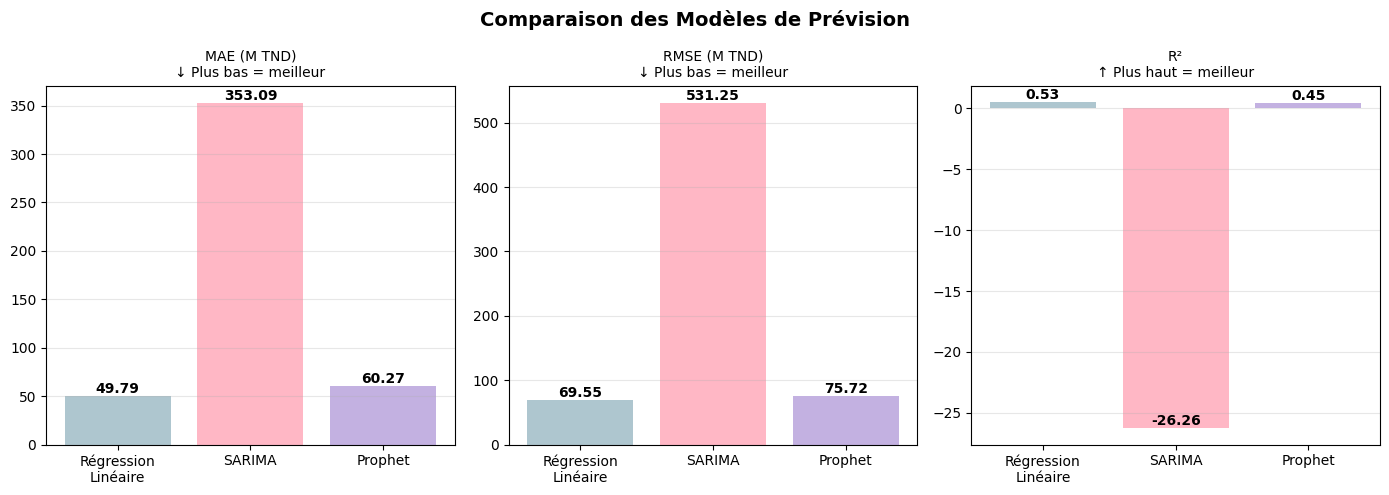

✅ Graphique sauvegardé dans plots/model_comparison.png


In [5]:
# =============================================
# TABLEAU COMPARATIF
# =============================================
results = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'SARIMA', 'Prophet'],
    'MAE (M TND)': [lr_mae/1e6, sarima_mae/1e6, prophet_mae/1e6],
    'RMSE (M TND)': [lr_rmse/1e6, sarima_rmse/1e6, prophet_rmse/1e6],
    'R²': [lr_r2, sarima_r2, prophet_r2]
})
results = results.round(3)
results['Classement'] = ['🥇', '🥉', '🥈']
print(results.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Comparaison des Modèles de Prévision', fontsize=14, fontweight='bold')

colors = ['#AEC6CF', '#FFB7C5', '#C3B1E1']
metrics = [
    ('MAE (M TND)', [lr_mae/1e6, sarima_mae/1e6, prophet_mae/1e6], '↓ Plus bas = meilleur'),
    ('RMSE (M TND)', [lr_rmse/1e6, sarima_rmse/1e6, prophet_rmse/1e6], '↓ Plus bas = meilleur'),
    ('R²', [lr_r2, sarima_r2, prophet_r2], '↑ Plus haut = meilleur'),
]

for ax, (title, values, note) in zip(axes, metrics):
    bars = ax.bar(['Régression\nLinéaire', 'SARIMA', 'Prophet'], values, color=colors)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(f'{title}\n{note}', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé dans plots/model_comparison.png")